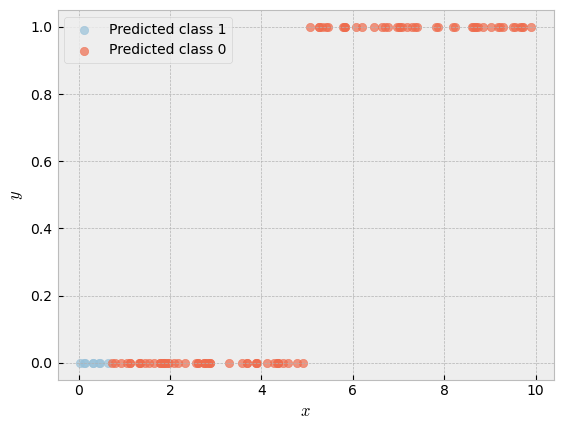

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.uniform(0, 10, 100)
noise = np.random.normal(0.5, 0.5, 100)
y = (x > 5).astype(int)

max_polynomial = 5

X = np.array([x**n for n in range(0,max_polynomial)]).T
w = np.random.standard_normal((max_polynomial))
y_pred = sigmoid(np.dot(X,w))

def plot_classes(x, y, y_pred):
    mask = y_pred > 0.5
    
    plt.scatter(x[mask], y[mask], c=colors[1], alpha=0.7, label="Predicted class 1")
    plt.scatter(x[~mask], y[~mask], c=colors[3], alpha=0.7, label="Predicted class 0")
    
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.grid(True)
    plt.legend()
    plt.show()

plot_classes(x, y, y_pred)




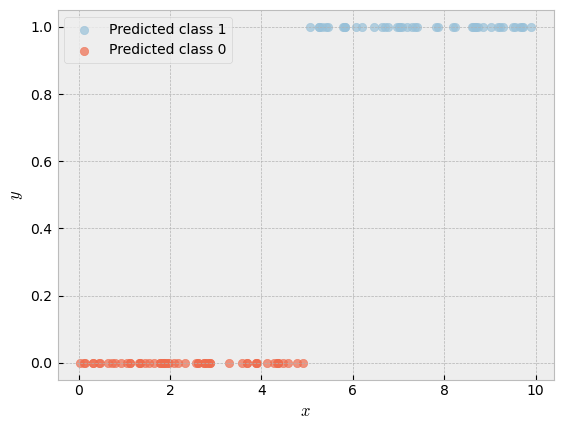

In [6]:
# gradient of negative log likelihood (log loss) is X^T(y_hat - y)
learning_rate = 0.0005;
loss_history = []

for i in range(10000):
    gradient = np.dot(X.T,(y_pred - y))
    w = w - (gradient*learning_rate)
    y_pred = sigmoid(np.dot(X,w))
    
    l2_error = np.linalg.norm(y_pred - y)
    loss_history += [l2_error]


plot_classes(x, y, y_pred)

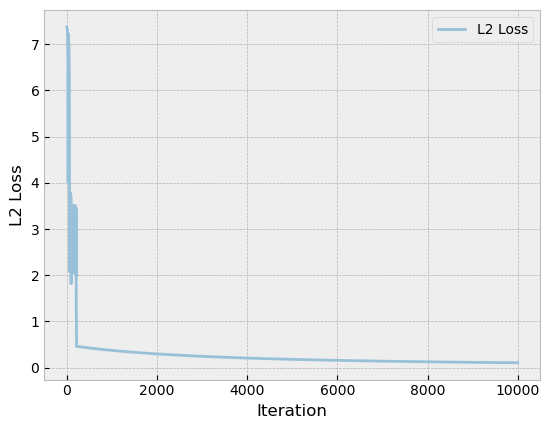

In [14]:
plt.plot(loss_history, c=colors[1], label="L2 Loss")
plt.xlabel('Iteration')
plt.ylabel('L2 Loss')
plt.legend()
# print("final loss: ", loss_history[-1])